In [238]:
import numpy as np
import pandas as pd
import os
import json
from datetime import datetime
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

<h3> LOADING FILES

In [200]:
data_submission=[]
path_submission="Dataset/json/submission"

for file in os.listdir(path_submission):
    if file.endswith('.json'):
        file_path= os.path.join(path_submission,file)
        with open(file_path, 'r', encoding='utf-8') as f:
            d = json.load(f)
            data_submission.extend(d)
df_submission = pd.DataFrame(data_submission)

data_comments=[]
path_comments="Dataset/json/comment"

for file in os.listdir(path_comments):
    if file.endswith('.json'):
        file_path= os.path.join(path_comments,file)
        with open(file_path, 'r', encoding='utf-8') as f:
            d = json.load(f)
            data_comments.extend(d)
df_comment = pd.DataFrame(data_comments)



In [201]:
df_submission.head()

,author,created_utc,id,num_comments,score,selftext,title,created
0,vkhuc,1413493797,2jgeao,8,26,,"Vowpal Wabbit, Liblinear/SBM and StreamSVM com...",1.413512e+09
1,bge0,1413492224,2jgb84,7,0,"Hello Everyone,\n\n\nWas just pondering this t...",0/1 Classification using Autoencoders,1.413510e+09
2,atveit,1413488277,2jg3j2,0,0,,Update with 162 new Deep Learning papers to th...,1.413506e+09
3,gwulfs,1413486402,2jfzwv,0,7,,SF Future of Data Science Party,1.413504e+09
4,__null__,1413474749,2jfd7u,10,0,I want to test a dataset in weka using either ...,Weka SMOreg and LIBSVM with linear kernel prob...,1.413493e+09


In [202]:
df_comment.head()


,author,body,created_utc,id,link_id,parent_id,score,created,total_awards_received
0,goblin_got_game,"Sure, go ahead, but I interned there just shor...",1413503491,clbl8y9,t3_2jd3f2,t1_clavggp,1,1.413521e+09,NaN
1,bge0,"Ah yes, good point. I am using an L2 Norm as m...",1413503382,clbl6yn,t3_2jgb84,t1_clbk82q,1,1.413521e+09,NaN
2,goblin_got_game,"Yes, firstly do the proactive things mentioned...",1413503007,clbl00o,t3_2jd3f2,t1_claxjkp,1,1.413521e+09,NaN
3,goblin_got_game,[This book has most of what you need](http://w...,1413502107,clbkjrb,t3_2jeg2h,t3_2jeg2h,2,1.413520e+09,NaN
4,goblin_got_game,&gt;I am just trying to evaluate how well the ...,1413501725,clbkd9n,t3_2jgb84,t3_2jgb84,1,1.413520e+09,NaN


<h3> Formatting Data

In [203]:
print(df_submission.shape)
df_submission.info()

(87835, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87835 entries, 0 to 87834
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   author        87835 non-null  object 
 1   created_utc   87835 non-null  int64  
 2   id            87835 non-null  object 
 3   num_comments  87835 non-null  int64  
 4   score         87835 non-null  int64  
 5   selftext      87061 non-null  object 
 6   title         87835 non-null  object 
 7   created       87835 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 5.4+ MB


In [204]:
print(df_comment.shape)
df_comment.info()

(224359, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224359 entries, 0 to 224358
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   author                 224359 non-null  object 
 1   body                   224359 non-null  object 
 2   created_utc            224359 non-null  int64  
 3   id                     224359 non-null  object 
 4   link_id                224359 non-null  object 
 5   parent_id              224359 non-null  object 
 6   score                  224359 non-null  int64  
 7   created                224359 non-null  float64
 8   total_awards_received  30997 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 15.4+ MB


In [205]:
removed_sub = (df_submission['selftext'] == "[removed]").sum()
deleted_sub = (df_submission['selftext'] == "[deleted]").sum()
print("submissions removed texts:", removed_sub)
print("submissions deleted text:", deleted_sub)

removed_com = (df_comment["body"] == "[removed]").sum()
deleted_com = (df_comment["body"] == "[deleted]").sum()
print("comments removed texts:", removed_com)
print("comments deleted text:", deleted_com)

submissions removed texts: 20965
submissions deleted text: 3716
comments removed texts: 945
comments deleted text: 9696


In [206]:
df_comment["created_utc"] = df_comment["created_utc"].apply(datetime.fromtimestamp)
df_comment.drop(["created","total_awards_received"], axis=1, inplace=True)
df_comment = df_comment[df_comment["body"] != "[removed]"]
df_comment = df_comment[df_comment["body"] != "[deleted]"]

In [207]:
df_submission["created_utc"] = df_submission["created_utc"].apply(datetime.fromtimestamp)
df_submission.drop(["created"], axis=1, inplace=True)
df_submission = df_submission[df_submission["selftext"] != "[removed]"]
df_submission = df_submission[df_submission["selftext"] != "[deleted]"]
df_submission['combined_text'] = df_submission['title'] + ' ' + df_submission['selftext']

In [208]:
df_submission.head()

,author,created_utc,id,num_comments,score,selftext,title,combined_text
0,vkhuc,2014-10-16 17:09:57,2jgeao,8,26,,"Vowpal Wabbit, Liblinear/SBM and StreamSVM com...","Vowpal Wabbit, Liblinear/SBM and StreamSVM com..."
1,bge0,2014-10-16 16:43:44,2jgb84,7,0,"Hello Everyone,\n\n\nWas just pondering this t...",0/1 Classification using Autoencoders,0/1 Classification using Autoencoders Hello Ev...
2,atveit,2014-10-16 15:37:57,2jg3j2,0,0,,Update with 162 new Deep Learning papers to th...,Update with 162 new Deep Learning papers to th...
3,gwulfs,2014-10-16 15:06:42,2jfzwv,0,7,,SF Future of Data Science Party,SF Future of Data Science Party
4,__null__,2014-10-16 11:52:29,2jfd7u,10,0,I want to test a dataset in weka using either ...,Weka SMOreg and LIBSVM with linear kernel prob...,Weka SMOreg and LIBSVM with linear kernel prob...


<h3> Defining ML Terms

In [209]:
ml_terms = {
    "SVM": ["support vector machine", "svm", "support vector"],
    "RNN": ["rnn", "recurrent neural network"],
    "LSTM": ["lstm", "long short term memory"],
    "GRU": ["gru", "gated recurrent unit"],
    "CNN": ["cnn", "convolutional neural network", "convnet"],
    "Neural Network": ["neural network", "neural net", "ann"],
    "Deep Learning": ["deep learning"],
    "Random Forest": ["random forest"],
    "Decision Tree": ["decision tree"],
    "XGBoost": ["xgboost", "xgb"],
    "Naive Bayes": ["naive bayes"],
    "KNN": ["knn", "k nearest neighbor"],
    "Linear Regression": ["linear regression"],
    "Logistic Regression": ["logistic regression"],
    "Transformer": ["transformer"],
    "BERT": ["bert"],
    "GPT": ["gpt"],
    "ResNet": ["resnet"],
    "GAN": ["gan", "generative adversarial"],
    "VAE": ["vae", "variational autoencoder"],
    "Autoencoder": ["autoencoder"],
    "TensorFlow": ["tensorflow"],
    "PyTorch": ["pytorch", "torch"],
    "Keras": ["keras"],
    "Scikit-learn": ["scikit learn", "sklearn"],
    "ReLU": ["relu"],
    "Sigmoid": ["sigmoid"],
    "Softmax": ["softmax"],
    "Adam": ["adam"],
    "SGD": ["sgd", "stochastic gradient descent"],
    "RMSprop": ["rmsprop"],
    "Dropout": ["dropout"],
    "Batch Normalization": ["batch normalization", "batch norm"],
    "Transfer Learning": ["transfer learning"],
    "Data Augmentation": ["data augmentation"],
    "Regularization": ["regularization"],
    "NLP": ["nlp", "natural language processing"],
    "Computer Vision": ["computer vision"],
    "Reinforcement Learning": ["reinforcement learning"],
    "Classification": ["classification"],
    "Regression": ["regression"],
    "Clustering": ["clustering"],
}

<h3> Tokenizing and Lemmatizing

In [210]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/shalavyaagrawal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shalavyaagrawal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [211]:
def helper(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\[discussion\]|\[d\]|\[news\]|\[n\]|\[research\]|\[r\]|\[project\]|\[p\]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    return text

def tokenize_lemmatize(text):
    if not text:
        return []
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word not in stop_words and len(word) > 2]
    return tokens

df_submission['cleaned_text'] = df_submission['combined_text'].apply(helper)
df_submission['tokens'] = df_submission['cleaned_text'].apply(tokenize_lemmatize)

df_comment['cleaned_text'] = df_comment['body'].apply(helper)
df_comment['tokens'] = df_comment['cleaned_text'].apply(tokenize_lemmatize)

<h3> Counting ML Terms

In [212]:
def count_ml_terms(tokens, terms_dict):
    text = ' '.join(tokens)
    term_counts = {}
    for t_name, vars in terms_dict.items():
        count = 0
        for var in vars:
            count += text.count(var.lower())
        term_counts[t_name] = count
    return term_counts


term_counts_sub = []
for tokens in df_submission['tokens']:
    counts = count_ml_terms(tokens, ml_terms)
    term_counts_sub.append(counts)

term_counts_df = pd.DataFrame(term_counts_sub)
df_submission = pd.concat([df_submission, term_counts_df], axis=1)
df_submission.dropna()

term_counts_com = []
for tokens in df_comment['tokens']:
    counts = count_ml_terms(tokens, ml_terms)
    term_counts_com.append(counts)

term_counts_df = pd.DataFrame(term_counts_com)
df_comment = pd.concat([df_comment, term_counts_df], axis=1)
df_comment.dropna()

,author,body,created_utc,id,link_id,parent_id,score,cleaned_text,tokens,SVM,...,Batch Normalization,Transfer Learning,Data Augmentation,Regularization,NLP,Computer Vision,Reinforcement Learning,Classification,Regression,Clustering
0,goblin_got_game,"Sure, go ahead, but I interned there just shor...",2014-10-16 19:51:31,clbl8y9,t3_2jd3f2,t1_clavggp,1.0,sure go ahead but i interned there just shor...,"[sure, ahead, interned, short, decade, ago, co...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,bge0,"Ah yes, good point. I am using an L2 Norm as m...",2014-10-16 19:49:42,clbl6yn,t3_2jgb84,t1_clbk82q,1.0,ah yes good point i am using an l2 norm as m...,"[yes, good, point, using, norm, cost, however,...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,goblin_got_game,"Yes, firstly do the proactive things mentioned...",2014-10-16 19:43:27,clbl00o,t3_2jd3f2,t1_claxjkp,1.0,yes firstly do the proactive things mentioned...,"[yes, firstly, proactive, thing, mentioned, re...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,goblin_got_game,[This book has most of what you need](http://w...,2014-10-16 19:28:27,clbkjrb,t3_2jeg2h,t3_2jeg2h,2.0,this book has most of what you need \n\ni wo...,"[book, need, would, add, dropout, rectified, l...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,goblin_got_game,&gt;I am just trying to evaluate how well the ...,2014-10-16 19:22:05,clbkd9n,t3_2jgb84,t3_2jgb84,1.0,gt i am just trying to evaluate how well the ...,"[trying, evaluate, well, signal, reconstructed...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213713,daikonrelish,Ya really cool paper but inference time seems ...,2016-10-24 21:53:54,d96h8co,t3_58qjiw,t1_d94l8z4,1.0,ya really cool paper but inference time seems ...,"[really, cool, paper, inference, time, seems, ...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
213714,rumblestiltsken,You specifically ask what might be most benefi...,2016-10-24 21:37:31,d96gjcj,t3_590h3z,t3_590h3z,2.0,you specifically ask what might be most benefi...,"[specifically, ask, might, beneficial, communi...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
213715,gwern,&gt; It is not free but Google can afford it. ...,2016-10-24 21:09:56,d96fchi,t3_58414p,t1_d96em00,1.0,gt it is not free but google can afford it ...,"[free, google, afford, point, google, afford, ...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
213716,MetricSpade007,Do you know of any hints of how to do this? Pa...,2016-12-18 18:57:00,dbd0530,t3_5iy6u9,t1_dbc5cdt,1.0,do you know of any hints of how to do this pa...,"[know, hint, particularly, possible, get, atte...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


<h3> Defining Date Features

In [213]:
df_submission['year'] = df_submission['created_utc'].dt.year
df_submission['month'] = df_submission['created_utc'].dt.month
df_submission['year_month'] = df_submission['created_utc'].dt.to_period('M')
df_submission['date'] = df_submission['created_utc'].dt.date

df_comment['year'] = df_comment['created_utc'].dt.year
df_comment['month'] = df_comment['created_utc'].dt.month
df_comment['year_month'] = df_comment['created_utc'].dt.to_period('M')
df_comment['date'] = df_comment['created_utc'].dt.date

<h3> Database creation

In [214]:
import sqlite3

conn = sqlite3.connect('reddit_ml.db')

df_submission_sql = df_submission.drop(['tokens', 'year_month'], axis=1)
df_comment_sql = df_comment.drop(['tokens', 'year_month'], axis=1)


df_submission_sql['created_utc'] = df_submission_sql['created_utc'].astype(str)
df_submission_sql['date'] = df_submission_sql['date'].astype(str)

df_comment_sql['created_utc'] = df_comment_sql['created_utc'].astype(str)
df_comment_sql['date'] = df_comment_sql['date'].astype(str)

df_submission_sql.to_sql('submissions', conn, if_exists='replace', index=False)

df_comment_sql.to_sql('comments', conn, if_exists='replace', index=False)

conn.close()


<h3> EDA

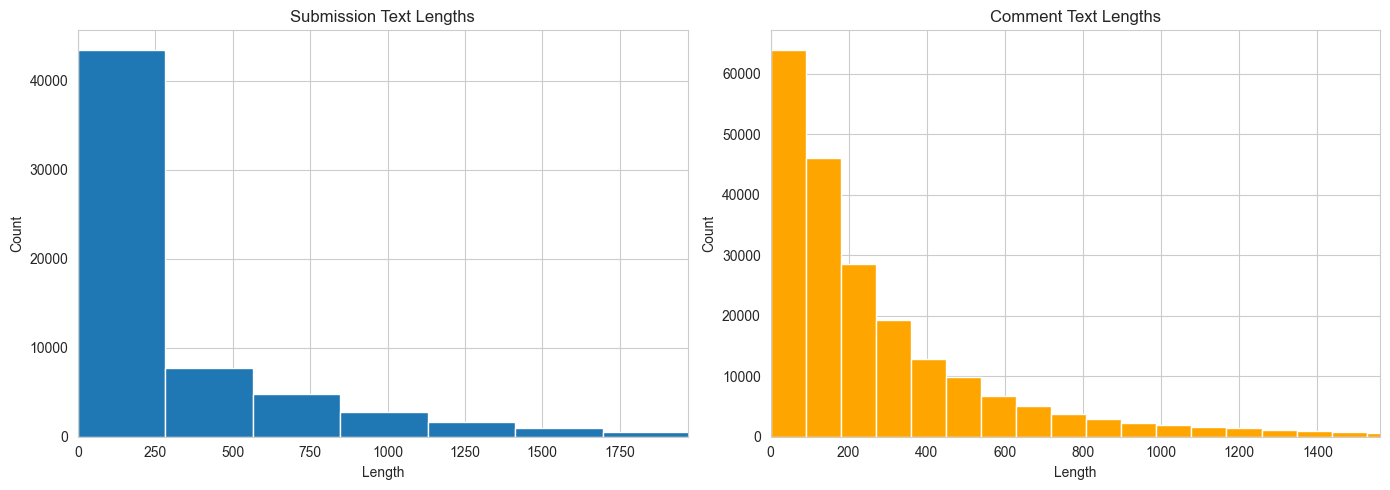

In [215]:
sub_len = df_submission['cleaned_text'].str.len()
com_len = df_comment['cleaned_text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sub_len, bins=110)
axes[0].set_title('Submission Text Lengths')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Count')
max_sub = sub_len[sub_len < sub_len.quantile(0.98)].max()
axes[0].set_xlim(0, max_sub)

axes[1].hist(com_len, bins=110, color = 'orange')
axes[1].set_title('Comment Text Lengths')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Count')
max_com = com_len[com_len < com_len.quantile(0.98)].max()
axes[1].set_xlim(0, max_com)

plt.tight_layout()
plt.show()

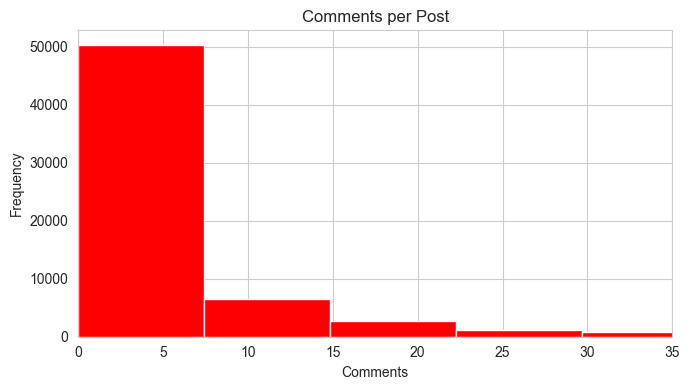

In [216]:
comment_counts = df_submission['num_comments']
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(comment_counts, bins=150, color= 'red')
ax.set_title('Comments per Post')
ax.set_xlabel('Comments')
ax.set_ylabel('Frequency')
upper = comment_counts.quantile(0.97)
ax.set_xlim(0, upper)

plt.tight_layout()
plt.show()


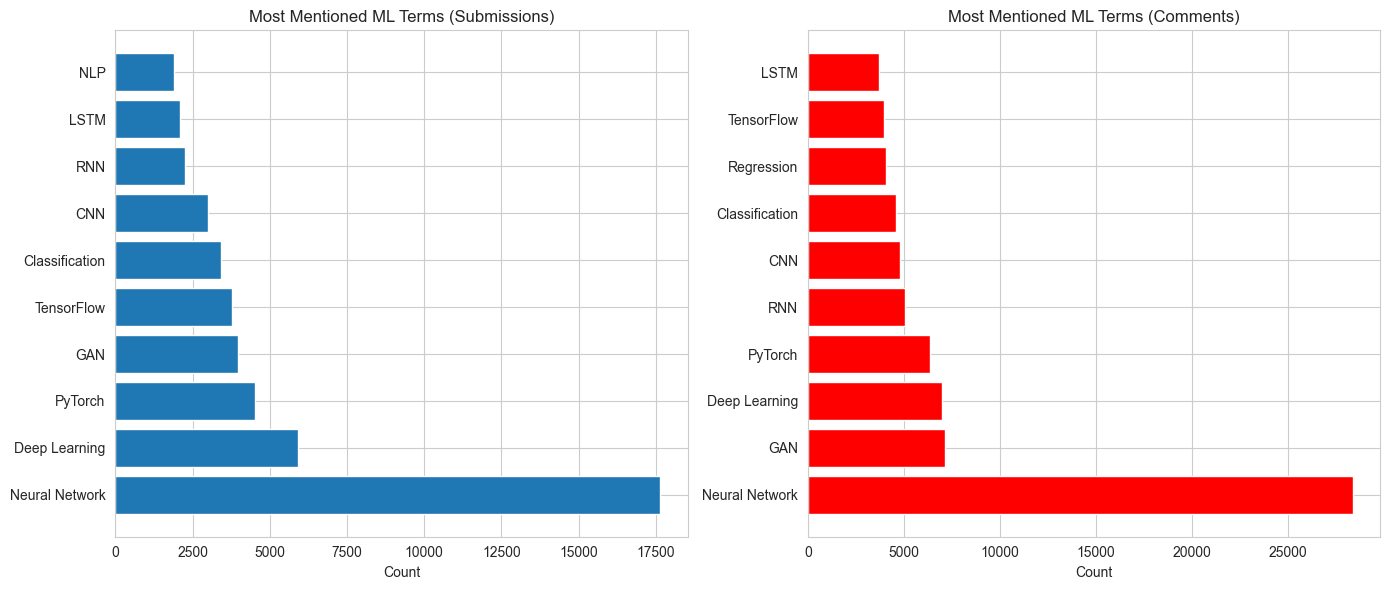

In [217]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sub_term_counts = (
    df_submission[list(ml_terms.keys())]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

axes[0].barh(sub_term_counts.index, sub_term_counts.values)
axes[0].set_title('Most Mentioned ML Terms (Submissions)')
axes[0].set_xlabel('Count')

com_term_counts = (
    df_comment[list(ml_terms.keys())]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

axes[1].barh(com_term_counts.index, com_term_counts.values, color = 'red')
axes[1].set_title('Most Mentioned ML Terms (Comments)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


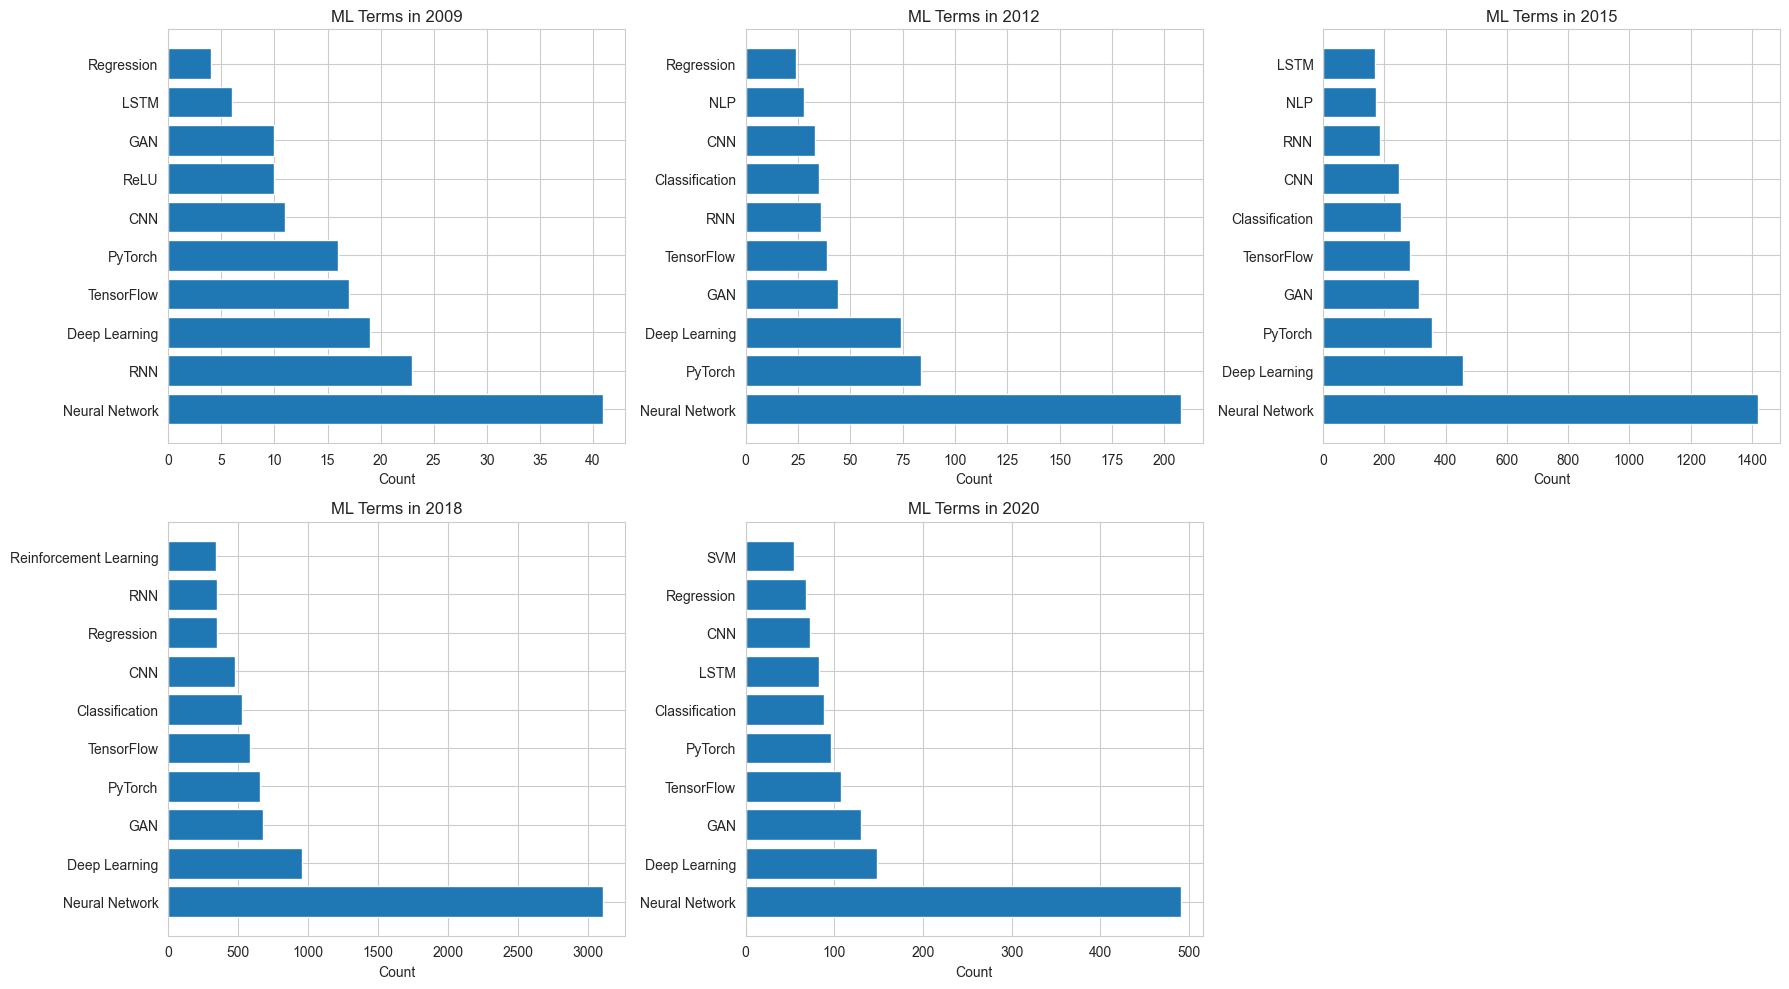

In [218]:
years = [2009, 2012, 2015, 2018, 2020]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, yr in enumerate(years):
    data_for_year = df_submission[df_submission['year'] == yr]
    term_counts = (
        data_for_year[list(ml_terms.keys())]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    ax = axes[idx]
    ax.barh(term_counts.index, term_counts.values)
    ax.set_title(f'ML Terms in {yr}')
    ax.set_xlabel('Count')

if len(years) < len(axes):
    for extra in range(len(years), len(axes)):
        axes[extra].set_visible(False)

plt.tight_layout()
plt.show()


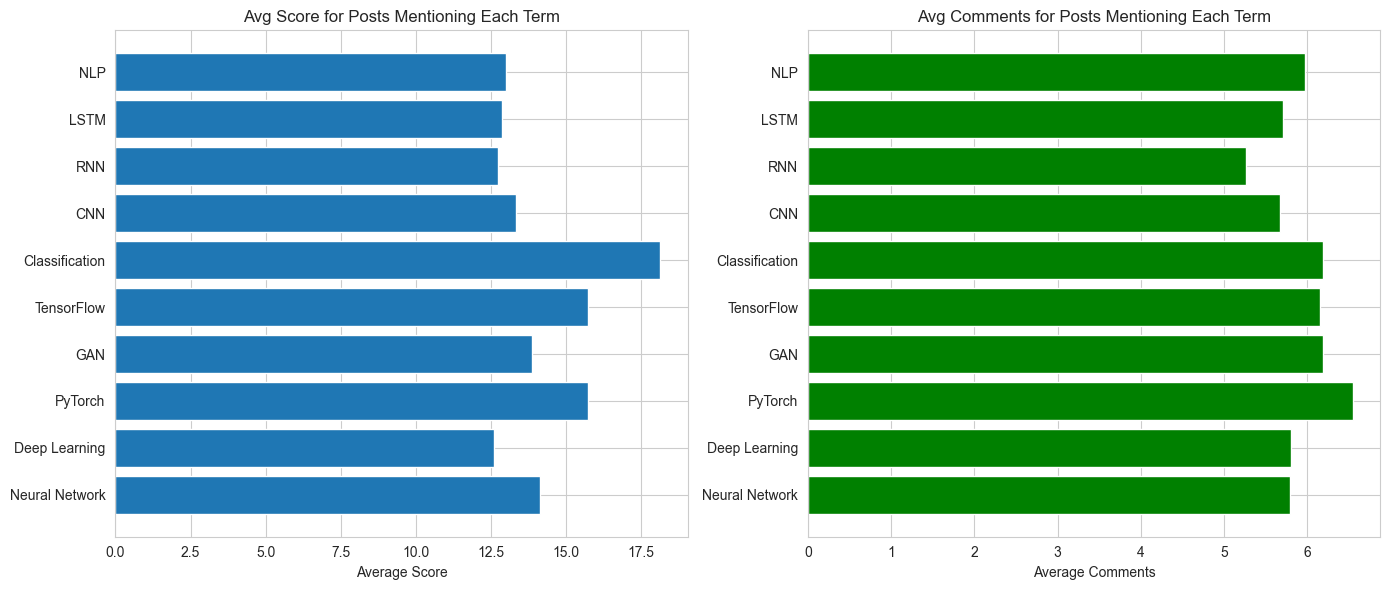

In [219]:
top_terms = (
    df_submission[list(ml_terms.keys())]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

avg_scores = []
avg_comment_counts = []

for term in top_terms:
    subset = df_submission[df_submission[term] > 0]
    avg_scores.append(subset['score'].mean())
    avg_comment_counts.append(subset['num_comments'].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_terms, avg_scores)
axes[0].set_title('Avg Score for Posts Mentioning Each Term')
axes[0].set_xlabel('Average Score')

axes[1].barh(top_terms, avg_comment_counts, color='green')
axes[1].set_title('Avg Comments for Posts Mentioning Each Term')
axes[1].set_xlabel('Average Comments')

plt.tight_layout()
plt.show()


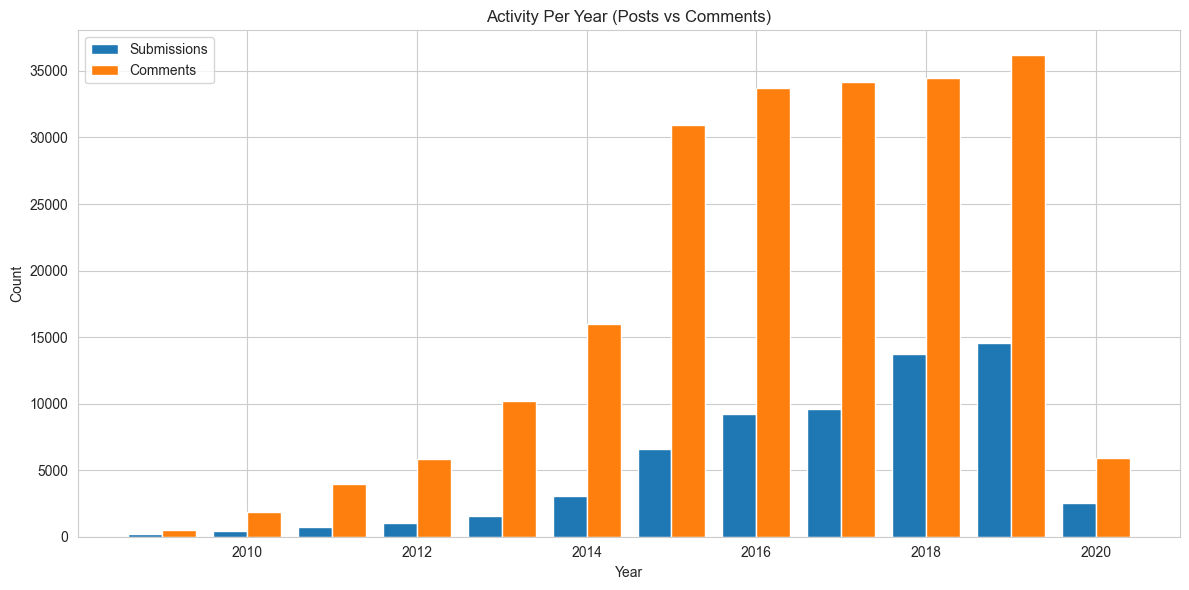

In [220]:
posts_per_year = df_submission.groupby('year').size()
comments_per_year = df_comment.groupby('year').size()

fig, ax = plt.subplots(figsize=(12, 6))
years = posts_per_year.index
bar_width = 0.4

ax.bar(years - bar_width/2, posts_per_year.values, 
       width=bar_width, label='Submissions')

ax.bar(years + bar_width/2, comments_per_year.values, 
       width=bar_width, label='Comments')

ax.set_title('Activity Per Year (Posts vs Comments)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()


<h3> Sentiment analysis using VADER

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
def get_vader_score(text):
    return analyzer.polarity_scores(str(text))['compound']

df_submission['sentiment'] = df_submission['cleaned_text'].apply(get_vader_score)
df_comment['sentiment'] = df_comment['cleaned_text'].apply(get_vader_score)

bins = [-1, -0.05, 0.05, 1]
labels = ['Negative', 'Neutral', 'Positive']

df_submission['sentiment_category'] = pd.cut(df_submission['sentiment'], bins=bins, labels=labels)
df_comment['sentiment_category']    = pd.cut(df_comment['sentiment'], bins=bins, labels=labels)

print("Submissions sentiment:")
print(df_submission['sentiment_category'].value_counts())

print("\nComments sentiment:")
print(df_comment['sentiment_category'].value_counts())


Submissions sentiment:
sentiment_category
Neutral     43342
Positive    30974
Negative     6521
Name: count, dtype: int64

Comments sentiment:
sentiment_category
Positive    136900
Neutral      52471
Negative     34493
Name: count, dtype: int64


In [222]:
top_terms = (
    df_submission[list(ml_terms.keys())]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
)

results = []

for term in top_terms:
    posts_with = df_submission[df_submission[term] > 0]
    posts_without = df_submission[df_submission[term] == 0]

    avg_with = posts_with['sentiment'].mean()
    avg_without = posts_without['sentiment'].mean()

    results.append({
        "term": term,
        "sentiment_with": avg_with,
        "sentiment_without": avg_without
    })

sentiment_df = pd.DataFrame(results)
print(sentiment_df)


             term  sentiment_with  sentiment_without
0  Neural Network        0.185840           0.191164
1   Deep Learning        0.205193           0.189403
2         PyTorch        0.197175           0.190372
3             GAN        0.182790           0.190830
4      TensorFlow        0.192638           0.190449
5  Classification        0.183339           0.190826
6             CNN        0.186011           0.190683
7             RNN        0.169125           0.190988
8            LSTM        0.192552           0.190508
9             NLP        0.202368           0.190289


In [223]:
sub_corr = df_submission[['sentiment', 'score']].corr().iloc[0, 1]
print("Correlation (submissions):", sub_corr)

com_corr = df_comment[['sentiment', 'score']].corr().iloc[0, 1]
print("Correlation (comments):", com_corr)


Correlation (submissions): -0.00630131986752068
Correlation (comments): 0.005048144421914635


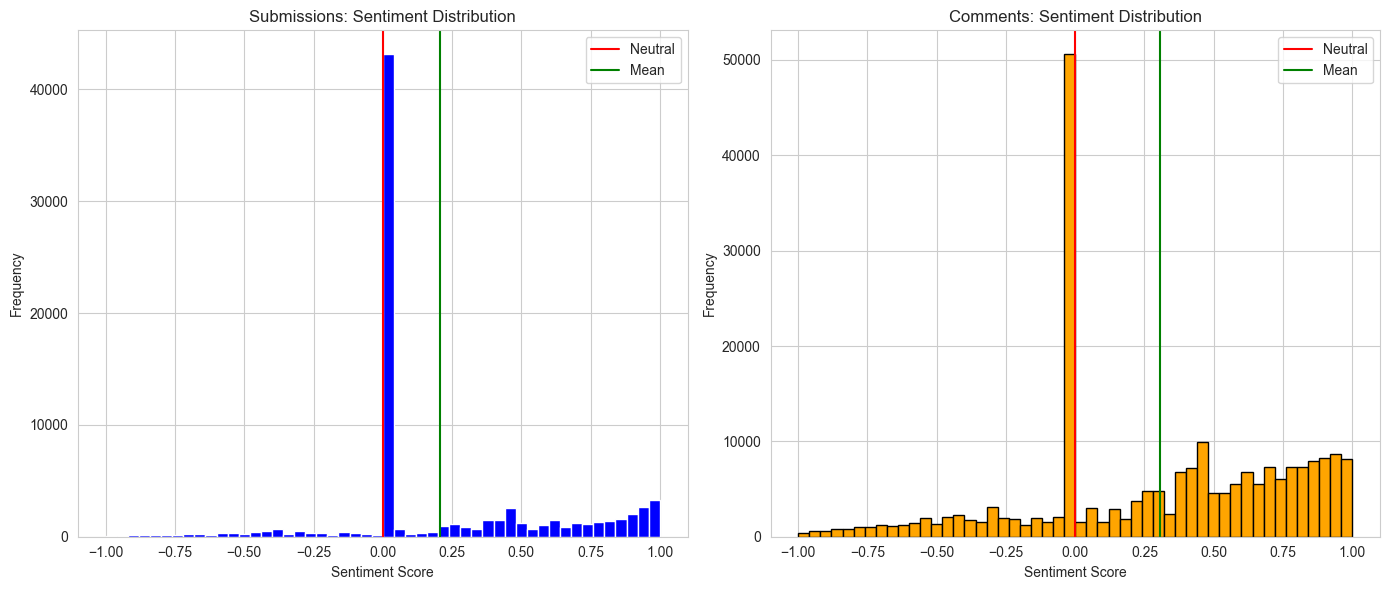

In [224]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].hist(df_submission['sentiment'], bins=50, color='blue')
axes[0].axvline(0, color='red', label='Neutral')
axes[0].axvline(df_submission['sentiment'].mean(), color='green', label='Mean')
axes[0].set_title('Submissions: Sentiment Distribution')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df_comment['sentiment'], bins=50, color='orange', edgecolor='black')
axes[1].axvline(0, color='red', label='Neutral')
axes[1].axvline(df_comment['sentiment'].mean(), color='green', label='Mean')
axes[1].set_title('Comments: Sentiment Distribution')
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()

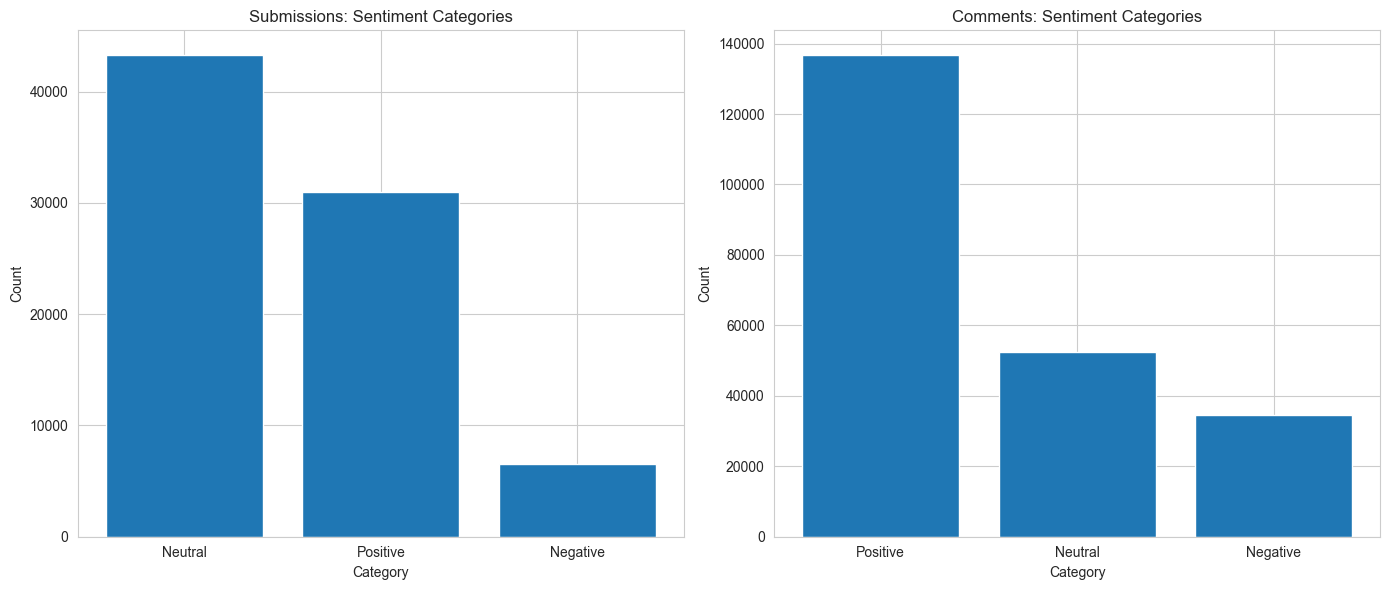

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sentiment_counts_sub = df_submission['sentiment_category'].value_counts()
axes[0].bar(sentiment_counts_sub.index, sentiment_counts_sub.values)
axes[0].set_title('Submissions: Sentiment Categories')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')

sentiment_counts_com = df_comment['sentiment_category'].value_counts()
axes[1].bar(sentiment_counts_com.index, sentiment_counts_com.values)
axes[1].set_title('Comments: Sentiment Categories')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')

plt.tight_layout()

In [226]:
conn = sqlite3.connect('reddit_ml.db')

df_submission_sql = df_submission.drop(['tokens', 'year_month'], axis=1, errors='ignore').copy()
df_comment_sql = df_comment.drop(['tokens', 'year_month'], axis=1, errors='ignore').copy()

df_submission_sql['created_utc'] = df_submission_sql['created_utc'].astype(str)
df_submission_sql['date'] = df_submission_sql['date'].astype(str)
df_submission_sql['sentiment_category'] = df_submission_sql['sentiment_category'].astype(str)

df_comment_sql['created_utc'] = df_comment_sql['created_utc'].astype(str)
df_comment_sql['date'] = df_comment_sql['date'].astype(str)
df_comment_sql['sentiment_category'] = df_comment_sql['sentiment_category'].astype(str)

df_submission_sql.to_sql('submissions', conn, if_exists='replace', index=False)
df_comment_sql.to_sql('comments', conn, if_exists='replace', index=False)
conn.close()

<h3>Time Series Analysis

In [ ]:
from prophet import Prophet

In [232]:
term_month = df_submission.groupby('year_month')[list(ml_terms.keys())].sum()
term_year = df_submission.groupby('year')[list(ml_terms.keys())].sum()
activ_sub = df_submission.groupby('year_month').size()
activ_com = df_comment.groupby('year_month').size()
sent_month = df_submission.groupby('year_month')['sentiment'].mean()

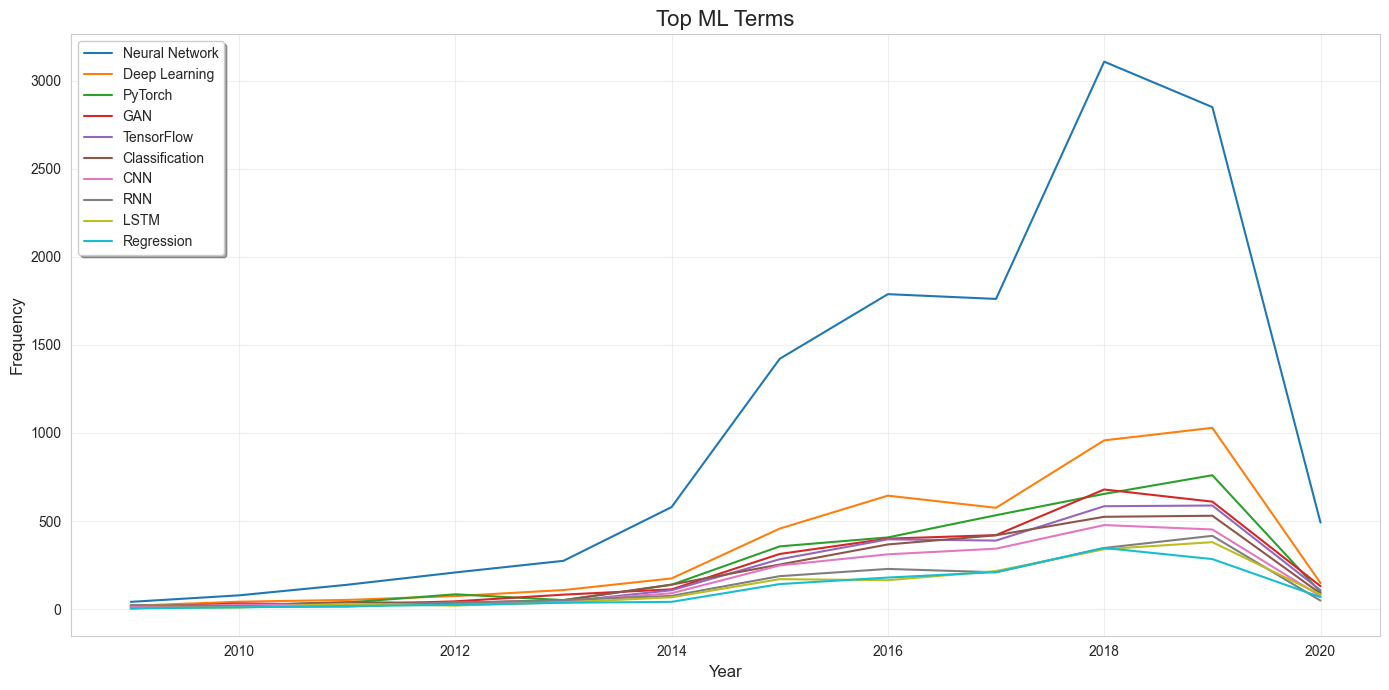

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
top = term_year.sum().sort_values(ascending=False).head(10).index
colors = plt.cm.tab10(range(10))
for idx, term in enumerate(top):
    ax.plot(term_year.index, term_year[term],label=term, color=colors[idx])

ax.set_title('Top ML Terms', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

12:40:55 - cmdstanpy - INFO - Chain [1] start processing
12:40:56 - cmdstanpy - INFO - Chain [1] done processing
12:40:56 - cmdstanpy - INFO - Chain [1] start processing
12:40:56 - cmdstanpy - INFO - Chain [1] done processing


Forecasting term: Neural Network
Forecasting term: Deep Learning


12:40:56 - cmdstanpy - INFO - Chain [1] start processing
12:40:56 - cmdstanpy - INFO - Chain [1] done processing


Forecasting term: PyTorch


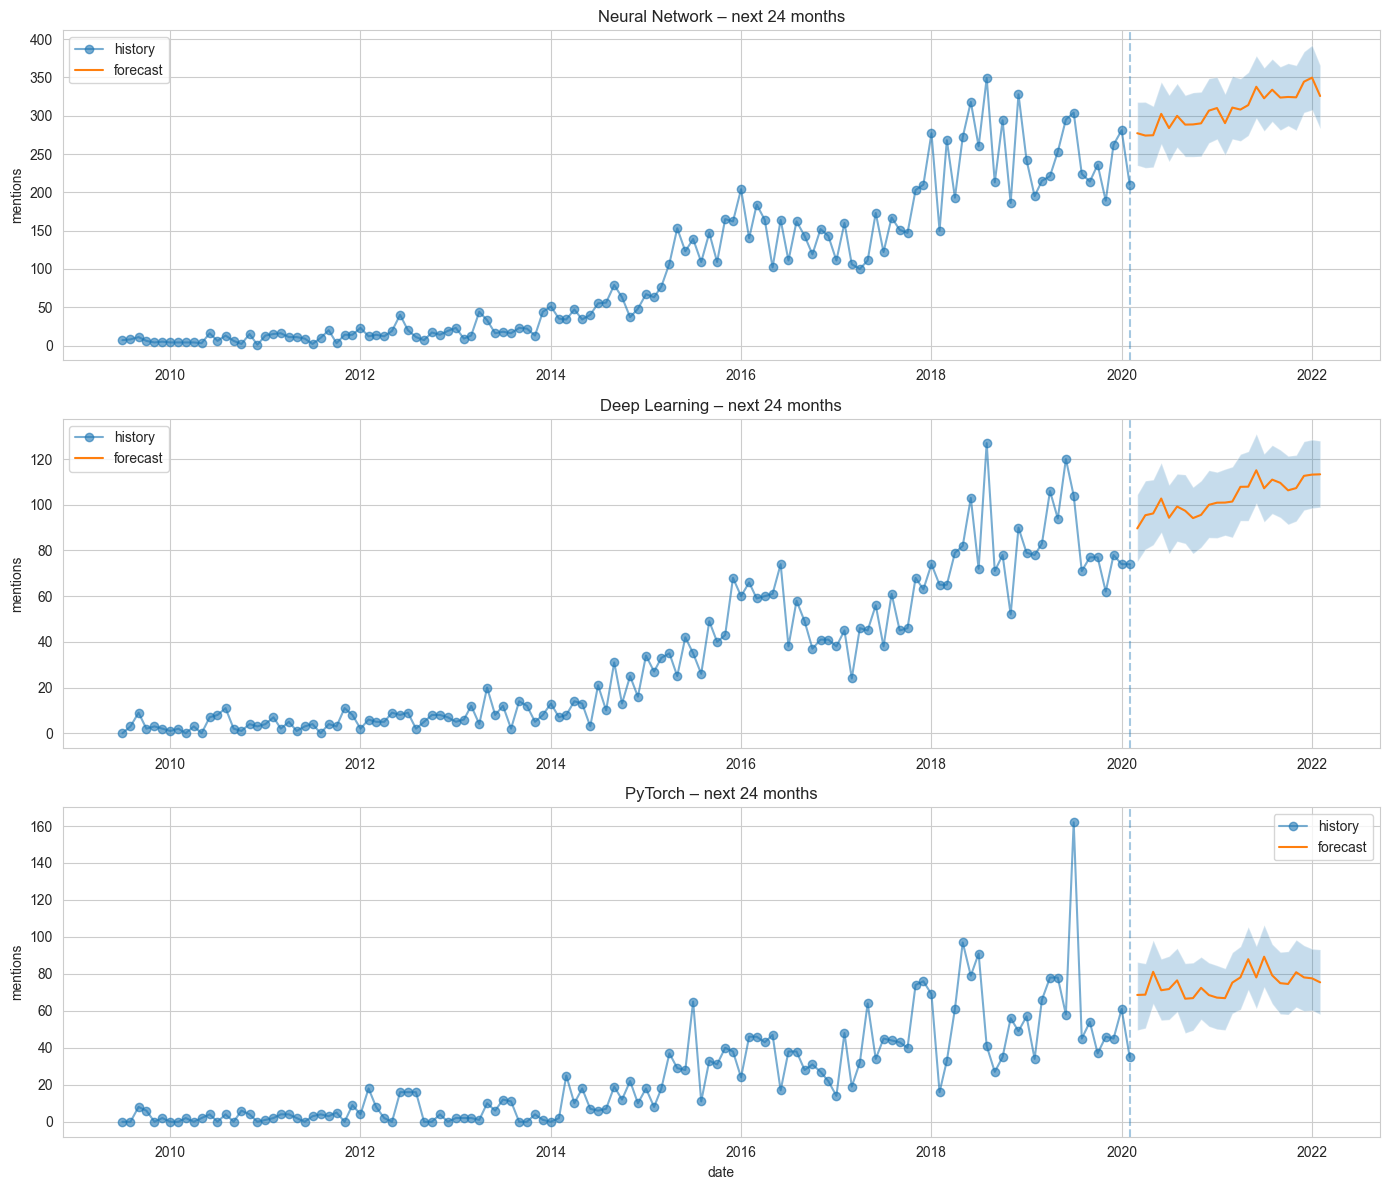

In [241]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
top_terms = term_year.sum().sort_values(ascending=False).head(3).index

for i, term in enumerate(top_terms):
    print(f"Forecasting term:",term)
    df_tmp = pd.DataFrame({"ds": term_month.index,
                           "y": term_month[term].values})

    m = Prophet(yearly_seasonality=True)
    m.fit(df_tmp)

    future = m.make_future_dataframe(periods=24, freq="MS")
    forecast = m.predict(future)
    ax = axes[i]
    ax.plot(df_tmp["ds"], df_tmp["y"], "o-", alpha=0.6, label="history")
    fcast = forecast[forecast["ds"] > df_tmp["ds"].max()]
    ax.plot(fcast["ds"], fcast["yhat"], label="forecast")

    ax.fill_between(fcast["ds"],fcast["yhat_lower"],fcast["yhat_upper"],alpha=0.25)
    ax.axvline(df_tmp["ds"].max(), linestyle="--", alpha=0.4)
    ax.set_title(f"{term} – next 24 months")
    ax.set_ylabel("mentions")
    ax.legend()
axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()


12:50:31 - cmdstanpy - INFO - Chain [1] start processing
12:50:31 - cmdstanpy - INFO - Chain [1] done processing


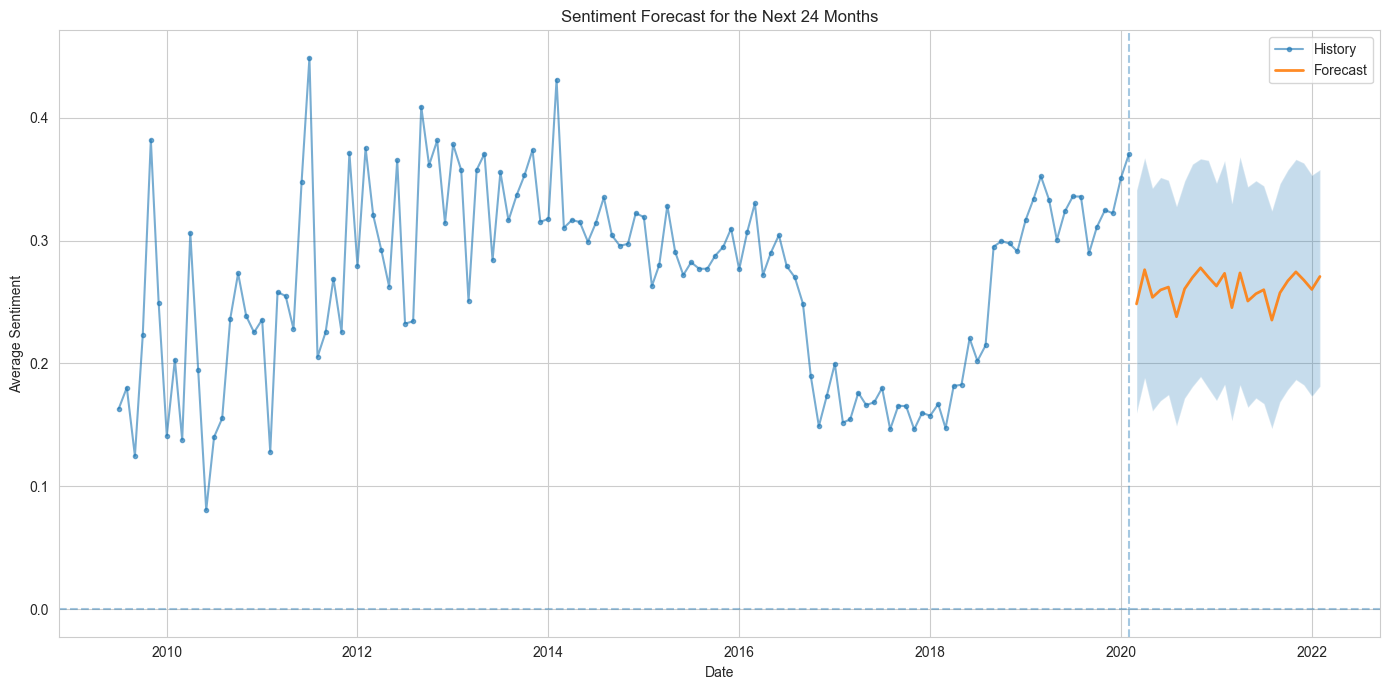

In [251]:
df = pd.DataFrame({'ds': sent_month.index, 'y': sent_month.values})

model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df)

future = model.make_future_dataframe(periods=24, freq="MS")
forecast = model.predict(future)
cutoff = df["ds"].max()
fcast = forecast[forecast["ds"] > cutoff]

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df["ds"], df["y"], "o-", alpha=0.6, ms=3, label="History")
ax.plot(fcast["ds"], fcast["yhat"], alpha=0.9, lw=2, label="Forecast")
ax.fill_between(fcast["ds"], fcast["yhat_lower"], fcast["yhat_upper"], alpha=0.25)
ax.axvline(cutoff, linestyle="--", alpha=0.4)
ax.axhline(0, linestyle="--", alpha=0.4)

ax.set_title("Sentiment Forecast for the Next 24 Months")
ax.set_xlabel("Date")
ax.set_ylabel("Average Sentiment")
ax.legend()

plt.tight_layout()
plt.show()